# Sensitivity analysis: what the impurity profile actually depends on

The standard estimate of oligonucleotide synthesis yield is a single number:

$$\text{full-length fraction} = c^{\,n-1}$$

where $c$ is the average stepwise coupling efficiency and $n$ is the length. It is
correct as far as it goes, and it is what every process spreadsheet computes.

But it answers only one question, and not the one that decides whether a batch
meets spec. Two crude mixtures can both be 87% full-length and behave completely
differently in purification. What matters is *what the other 13% is made of*.

This notebook uses `oligosim` to show three things the scalar estimate cannot:

1. How steeply the impurity burden grows as coupling efficiency drops
2. Why length is punishing, and where it becomes the dominant term
3. **That capping does not improve yield at all** — it converts a hard separation
   problem into an easy one, which is a different and more useful thing

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from oligosim import Oligo, ProcessConditions, Sugar, Linkage, simulate

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Nusinersen: 18-mer, uniform 2'-O-MOE, full phosphorothioate, 5-methyl-C.
# A real approved drug substance, so the numbers below are not hypothetical.
NUSINERSEN = Oligo.from_string(
    "TmCAmCTTTmCATAATGmCTGG", sugar=Sugar.MOE, linkage=Linkage.PS
)

print(NUSINERSEN.sequence_5to3)
print(f"n = {NUSINERSEN.n}, couplings = {NUSINERSEN.n_couplings}")
print(f"monoisotopic mass = {NUSINERSEN.mass():.3f} Da")

TCACTTTCATAATGCTGG [2'-MOE, PS]
n = 18, couplings = 17
monoisotopic mass = 7122.276 Da


## 1. Coupling efficiency

Sweep $c$ across the range a real synthesizer operates in. Note the axis: the
whole span is 98% to 99.9%, because that is the entire range that matters. The
difference between a routine batch and an unpurifiable one lives in the second
decimal place.

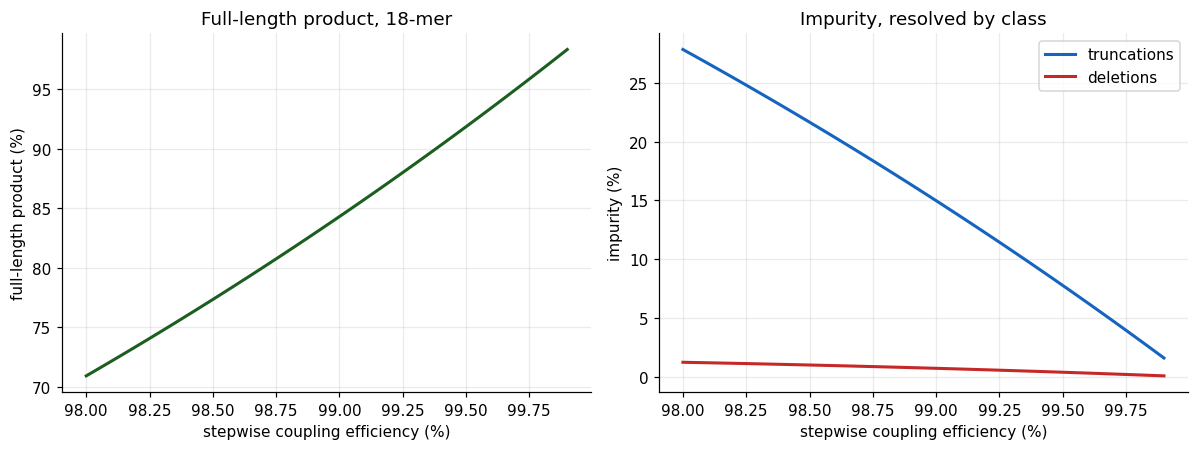

c=0.980   FLP= 70.93%   deletions= 1.24%   truncations= 27.83%
c=0.990   FLP= 84.29%   deletions= 0.73%   truncations= 14.98%
c=0.992   FLP= 87.24%   deletions= 0.60%   truncations= 12.16%
c=0.995   FLP= 91.83%   deletions= 0.39%   truncations=  7.78%
c=0.999   FLP= 98.31%   deletions= 0.08%   truncations=  1.60%


In [2]:
couplings = np.linspace(0.980, 0.999, 40)

flp, dele, trunc = [], [], []
for c in couplings:
    r = simulate(NUSINERSEN, ProcessConditions(coupling_efficiency=c,
                                               capping_efficiency=0.95))
    flp.append(r.full_length_fraction * 100)
    dele.append(r.deletion_fraction * 100)
    trunc.append(r.truncation_fraction * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.plot(couplings * 100, flp, lw=2, color="#1b5e20")
ax1.set_xlabel("stepwise coupling efficiency (%)")
ax1.set_ylabel("full-length product (%)")
ax1.set_title("Full-length product, 18-mer")

ax2.plot(couplings * 100, trunc, lw=2, label="truncations", color="#1565c0")
ax2.plot(couplings * 100, dele, lw=2, label="deletions", color="#c62828")
ax2.set_xlabel("stepwise coupling efficiency (%)")
ax2.set_ylabel("impurity (%)")
ax2.set_title("Impurity, resolved by class")
ax2.legend()

plt.tight_layout()
plt.show()

for c in (0.980, 0.990, 0.992, 0.995, 0.999):
    r = simulate(NUSINERSEN, ProcessConditions(coupling_efficiency=c,
                                               capping_efficiency=0.95))
    print(f"c={c:.3f}   FLP={r.full_length_fraction:7.2%}   "
          f"deletions={r.deletion_fraction:6.2%}   "
          f"truncations={r.truncation_fraction:7.2%}")

Dropping from 99.5% to 98.0% coupling costs about 21 points of full-length
product on an 18-mer. That is the well-known part.

The right-hand panel is the part the scalar estimate hides. Truncations dominate
the impurity mass by roughly twenty to one, but deletions are the ones that hurt
in purification, because a chain missing one internal residue co-elutes closely
with product while a short truncation does not. Tracking only total impurity
would tell you those two curves are the same problem. They are not.

## 2. Length

Same sweep, four lengths. This is where the exponent does its work.

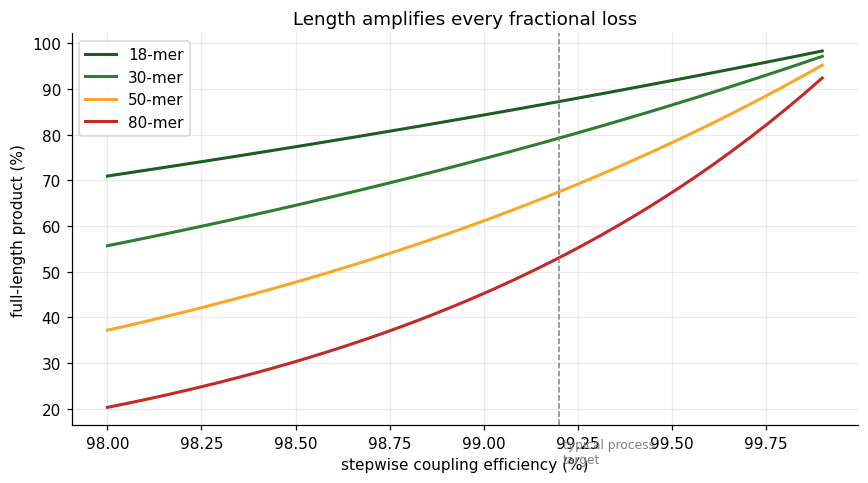

At c = 0.992:
  18-mer   FLP= 87.24%   single deletions= 0.60%
  30-mer   FLP= 79.22%   single deletions= 0.93%
  50-mer   FLP= 67.46%   single deletions= 1.33%
  80-mer   FLP= 53.02%   single deletions= 1.69%


In [3]:
lengths = [18, 30, 50, 80]
colors = ["#1b5e20", "#2e7d32", "#f9a825", "#c62828"]

fig, ax = plt.subplots()
for n, color in zip(lengths, colors):
    oligo = Oligo.from_string("A" * n, sugar=Sugar.MOE, linkage=Linkage.PS)
    # full-length fraction is the zero-deletion species, so it is exact at
    # any max_deletions. Tracking shallowly here is a ~1000x speedup on the
    # 80-mer with no loss of accuracy in what this chart plots.
    ys = [
        simulate(oligo, ProcessConditions(coupling_efficiency=c,
                                          capping_efficiency=0.95),
                 max_deletions=0).full_length_fraction * 100
        for c in couplings
    ]
    ax.plot(couplings * 100, ys, lw=2, color=color, label=f"{n}-mer")

ax.axvline(99.2, ls="--", lw=1, color="grey")
ax.text(99.21, 8, "typical process\ntarget", fontsize=8, color="grey")
ax.set_xlabel("stepwise coupling efficiency (%)")
ax.set_ylabel("full-length product (%)")
ax.set_title("Length amplifies every fractional loss")
ax.legend()
plt.tight_layout()
plt.show()

print("At c = 0.992:")
for n in lengths:
    oligo = Oligo.from_string("A" * n, sugar=Sugar.MOE, linkage=Linkage.PS)
    r = simulate(oligo, ProcessConditions(coupling_efficiency=0.992,
                                          capping_efficiency=0.95),
                 max_deletions=1)
    print(f"  {n:2d}-mer   FLP={r.full_length_fraction:7.2%}   "
          f"single deletions={r.deletion_fraction:6.2%}")

At a fixed 99.2% coupling, full-length product falls from about 87% at 18
residues to about 53% at 80. Nothing about the chemistry changed — only the
number of chances to fail.

This is the quantitative reason therapeutic oligonucleotides cluster in the
18–25mer range, and the reason longer constructs demand either much better
chemistry or a different manufacturing route entirely.

**A note on cost.** Exact tracking to $k$ deletions on an $n$-mer needs
$\sum_{j=0}^{k}\binom{n-1}{j}$ states, which grows fast: an 18-mer to 3 deletions is
834 states and runs in milliseconds, but an 80-mer is 82,240 states and takes
close to a minute. The chart above sidesteps this — full-length product is the
zero-deletion species, so it is exact at `max_deletions=0`. Deep tracking is only
needed when the impurity *breakdown* matters.

## 3. Capping: the result worth looking at twice

Capping acetylates chains that failed to couple, removing them from the growing
population permanently. It is easy to assume this improves yield. It does not.

A chain is full-length only if it coupled successfully on *every* cycle. Capping
acts on chains that already failed. So the full-length fraction is $\prod c_i$
regardless of how well capping works.

What capping changes is what the failures *become*:

- **Capped** → a short truncation. Elutes far from product. Easy to remove.
- **Uncapped** → survives, couples in a later cycle, and becomes a **deletion
  sequence**: full-length minus one internal residue. Co-elutes closely with
  product. Hard to remove.

Hold coupling fixed and sweep capping.

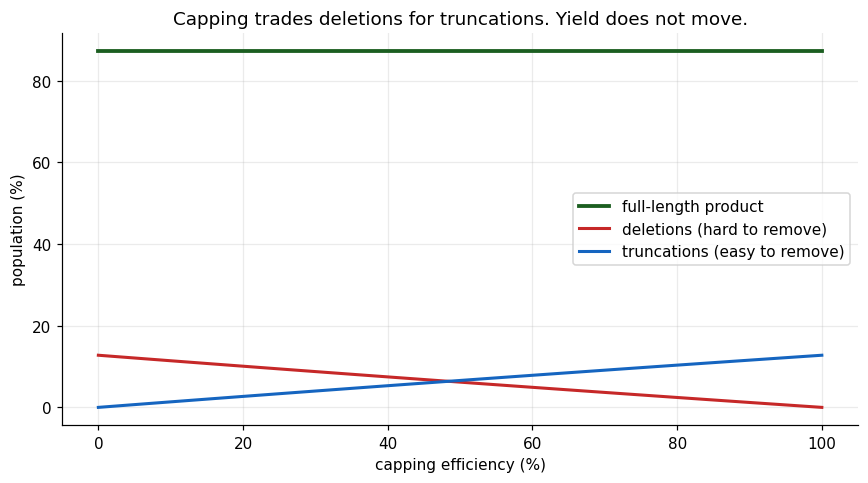

coupling held at 0.992 throughout:

capping=0.00   FLP=87.2365%   deletions=12.7635%   truncations= 0.0000%


capping=0.50   FLP=87.2365%   deletions=6.1768%   truncations= 6.5867%


capping=0.80   FLP=87.2365%   deletions=2.4231%   truncations=10.3404%


capping=0.95   FLP=87.2365%   deletions=0.5999%   truncations=12.1635%
capping=1.00   FLP=87.2365%   deletions=0.0000%   truncations=12.7635%


In [4]:
cappings = np.linspace(0.0, 1.0, 40)

flp_k, del_k, trunc_k = [], [], []
for k in cappings:
    r = simulate(NUSINERSEN,
                 ProcessConditions(coupling_efficiency=0.992, capping_efficiency=k),
                 max_deletions=6)
    flp_k.append(r.full_length_fraction * 100)
    del_k.append(r.deletion_fraction * 100)
    trunc_k.append(r.truncation_fraction * 100)

fig, ax = plt.subplots()
ax.plot(cappings * 100, flp_k, lw=2.5, color="#1b5e20", label="full-length product")
ax.plot(cappings * 100, del_k, lw=2, color="#c62828", label="deletions (hard to remove)")
ax.plot(cappings * 100, trunc_k, lw=2, color="#1565c0", label="truncations (easy to remove)")
ax.set_xlabel("capping efficiency (%)")
ax.set_ylabel("population (%)")
ax.set_title("Capping trades deletions for truncations. Yield does not move.")
ax.legend()
plt.tight_layout()
plt.show()

print("coupling held at 0.992 throughout:\n")
for k in (0.0, 0.5, 0.8, 0.95, 1.0):
    r = simulate(NUSINERSEN,
                 ProcessConditions(coupling_efficiency=0.992, capping_efficiency=k),
                 max_deletions=6)
    print(f"capping={k:.2f}   FLP={r.full_length_fraction:8.4%}   "
          f"deletions={r.deletion_fraction:7.4%}   "
          f"truncations={r.truncation_fraction:8.4%}")

The full-length line is flat at 87.237% across the entire sweep — not
approximately flat, exactly flat. Meanwhile deletions fall from 12.763% to zero
and truncations rise from zero to 12.763%. The impurity is conserved and simply
moves between classes.

This is enforced as a test invariant in the package, because any bug in the
population bookkeeping would break it.

It is also the clearest illustration of why a scalar yield estimate is not
enough. Improving capping from 50% to 95% does nothing measurable to yield, so a
$c^{\,n-1}$ calculation says the change was worthless. In reality it cut the
hard-to-separate impurity by a factor of ten, which is the difference between a
straightforward purification and a painful one.

## 4. Which cycle is costing you purity

When coupling efficiency varies by position — different amidites couple at
different rates, and bulky 2' modifications are measurably slower — the model
attributes deletions to the cycle that produced them.

Here a single sluggish coupling is introduced at position 9, as might happen with
a difficult monomer or a partially degraded amidite lot.

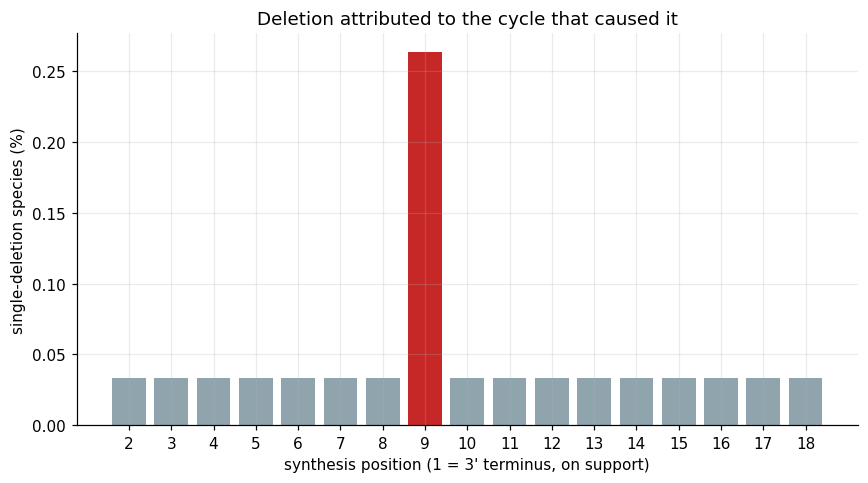

full-length product: 82.66%
deletion at position 9: 0.2638%
deletion at a normal position: 0.0333%

ratio: 7.9x


In [5]:
cond = ProcessConditions(
    coupling_efficiency=0.992,
    capping_efficiency=0.95,
    coupling_overrides={9: 0.94},   # one bad cycle
)
r = simulate(NUSINERSEN, cond)

by_pos = r.deletions_by_position()
positions = sorted(by_pos)
values = [by_pos[p] * 100 for p in positions]

fig, ax = plt.subplots()
bars = ax.bar(positions, values,
              color=["#c62828" if p == 9 else "#90a4ae" for p in positions])
ax.set_xlabel("synthesis position (1 = 3' terminus, on support)")
ax.set_ylabel("single-deletion species (%)")
ax.set_title("Deletion attributed to the cycle that caused it")
ax.set_xticks(positions)
plt.tight_layout()
plt.show()

print(f"full-length product: {r.full_length_fraction:.2%}")
print(f"deletion at position 9: {by_pos[9]:.4%}")
print(f"deletion at a normal position: {by_pos[8]:.4%}")
print(f"\nratio: {by_pos[9] / by_pos[8]:.1f}x")

One cycle at 94% instead of 99.2% produces roughly eight times the deletion
burden of a normal cycle at that position, and it is immediately visible.

This is the diagnostic a process chemist actually needs when a batch misses spec.
Trityl monitoring on the synthesizer gives per-cycle coupling efficiency; this
converts that into a predicted impurity profile and points at the offending
cycle.

## What this model does not yet include

The predictions above are optimistic, and it is worth being explicit about by how
much and why.

For an 18-mer 2'-OMe phosphorothioate oligonucleotide, published work on
membrane-enabled liquid-phase synthesis reports crude purity around **72%**. This
model predicts about **87%** full-length at 99.2% coupling. The ~15 point gap is
not a bug — it is the set of impurity classes v0.1 does not model:

| Missing | Why it matters |
|---|---|
| PO-for-PS mismatches | Computed here as an independent marginal, not folded into the population. For 17 PS linkages at 99.5% sulfurization, only ~92% of chains are fully sulfurized. |
| Depurination | Acid-catalysed, dA-dominated, accumulates with cycle count. |
| Cyanoethyl adducts | Acrylonitrile released during deprotection is a Michael acceptor; adducts form preferentially on thymine. |
| n+1 insertions | From premature detritylation of the incoming amidite. |
| Cleavage/deprotection losses | Not modelled at all. |

Folding the sulfurization state into the joint population is the single largest
of these and is the first item in v0.2.

**Every kinetic parameter used above is a placeholder**, not a calibrated value.
Read these curves for their *shape* — the steepness of the coupling dependence,
the flatness of the capping line — rather than for their absolute numbers.